# COVID-19 India Data: Exploratory Data Analysis & ETL Blueprint

In this notebook, we perform an initial Exploratory Data Analysis (EDA) on the raw COVID-19 datasets (Cases, Testing, and Vaccinations). The goal is to understand the structure of the data, discover any data quality issues, and blueprint the necessary data cleaning and feature engineering steps for our automated SQL ETL pipeline.

## Insights for ETL Pipeline Blueprint (Based on Findings Below)

### Insights (Cases Data)
Looking at the lowest frequency categories, we clearly spot several issues:
- **Typos**: `Karanataka`, `Himanchal Pradesh`, `Telengana`
- **Special Characters**: `Bihar****`, `Madhya Pradesh***`, `Maharashtra***`
- **Unassigned/Reassigned Data**: `Unassigned`, `Cases being reassigned to states`
- **Repetition**: `Daman & Diu` , `Dadra and Nagar Haveli` ,`Dadra and Nagar Haveli and Daman and Diu` only the combination should be kept.

### Insights (Testing Data)
1. **Missing Values**: there are a lot of missing values for `positive` and `negative` columns, moreover there are values missing for `negative` even when `positive` contains a value.
2. **State Names**: are perfect in this dataset unlike cases data

### Insights (Vaccination Data)
- There was India mentioned as state and rows included its data.
- Using above analysis we see that it represents the all states data collectively mentioned as India.
- We will need to handle this accordingly.

### Features that can be engineered
- The data is cumulative, to observe daily cases we can create a new feature named `daily_new_cases` i.e `confirmed` - LAG(`confirmed`, 1) - 1 
- `population` feature can be added, which would be a static value for each state. This would help justify other features more, for example larger population may have a little higher positives than a small population state but the overall positive rate maybe
 be lower for the larger population.

- To measure the fatality rate, we can create `case_fatality_rate` as  (`deaths`/`confirmed`)*100.
- To measure the ratio of positive cases, `positive_test_rate` as `postive`/`total_samples`.
- To measure how much of the population is vaccinated and its impacts, `vaccination_rate` as (`total_doses_adminstered`/`population`)*100

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

## 1. Data Ingestion
We start by loading the raw datasets: statewise cases, testing details, and vaccination details.

In [4]:
# Load the raw CSV files
cases_df = pd.read_csv('../data/raw/covid_19_india.csv')
testing_df = pd.read_csv('../data/raw/StatewiseTestingDetails.csv')
vaccine_df = pd.read_csv('../data/raw/covid_vaccine_statewise.csv')

print("Cases dataset shape:", cases_df.shape)
print("Testing dataset shape:", testing_df.shape)
print("Vaccine dataset shape:", vaccine_df.shape)

Cases dataset shape: (18110, 9)
Testing dataset shape: (16336, 5)
Vaccine dataset shape: (7845, 24)


## 2. Initial Data Inspection: Cases Dataset
Let's look at the first few rows, the data types, and basic summary statistics of the primary `cases_df` dataset.

In [9]:
cases_df.head()

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3


In [10]:
cases_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Sno                       18110 non-null  int64 
 1   Date                      18110 non-null  object
 2   Time                      18110 non-null  object
 3   State/UnionTerritory      18110 non-null  object
 4   ConfirmedIndianNational   18110 non-null  object
 5   ConfirmedForeignNational  18110 non-null  object
 6   Cured                     18110 non-null  int64 
 7   Deaths                    18110 non-null  int64 
 8   Confirmed                 18110 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ MB


In [11]:
# Summary statistics for numerical columns
cases_df.describe()

,Sno,Cured,Deaths,Confirmed
count,18110.000000,1.811000e+04,18110.000000,1.811000e+04
mean,9055.500000,2.786375e+05,4052.402264,3.010314e+05
std,5228.051023,6.148909e+05,10919.076411,6.561489e+05
min,1.000000,0.000000e+00,0.000000,0.000000e+00
25%,4528.250000,3.360250e+03,32.000000,4.376750e+03
50%,9055.500000,3.336400e+04,588.000000,3.977350e+04
75%,13582.750000,2.788698e+05,3643.750000,3.001498e+05
max,18110.000000,6.159676e+06,134201.000000,6.363442e+06


From the summary statistics, we can see that `Cured`, `Deaths`, and `Confirmed` cases have a wide range, which makes sense given the varying sizes of Indian states and the progression of the pandemic over time.




## 3. Investigating Categorical Data & Data Quality (Cases Data)

In [13]:
# the unique values in the 'State/UnionTerritory' column
unique_states = cases_df['State/UnionTerritory'].unique()
print(f"Number of unique states/UTs found: {len(unique_states)}\n")
print(unique_states)

Number of unique states/UTs found: 46

['Kerala' 'Telengana' 'Delhi' 'Rajasthan' 'Uttar Pradesh' 'Haryana'
 'Ladakh' 'Tamil Nadu' 'Karnataka' 'Maharashtra' 'Punjab'
 'Jammu and Kashmir' 'Andhra Pradesh' 'Uttarakhand' 'Odisha' 'Puducherry'
 'West Bengal' 'Chhattisgarh' 'Chandigarh' 'Gujarat' 'Himachal Pradesh'
 'Madhya Pradesh' 'Bihar' 'Manipur' 'Mizoram'
 'Andaman and Nicobar Islands' 'Goa' 'Unassigned' 'Assam' 'Jharkhand'
 'Arunachal Pradesh' 'Tripura' 'Nagaland' 'Meghalaya'
 'Dadra and Nagar Haveli and Daman and Diu'
 'Cases being reassigned to states' 'Sikkim' 'Daman & Diu' 'Lakshadweep'
 'Telangana' 'Dadra and Nagar Haveli' 'Bihar****' 'Madhya Pradesh***'
 'Himanchal Pradesh' 'Karanataka' 'Maharashtra***']


India has 28 states and 8 Union Territories (36 total), but we have over 40 unique values here. Let's visualize the frequency of records per state to spot anomalies.

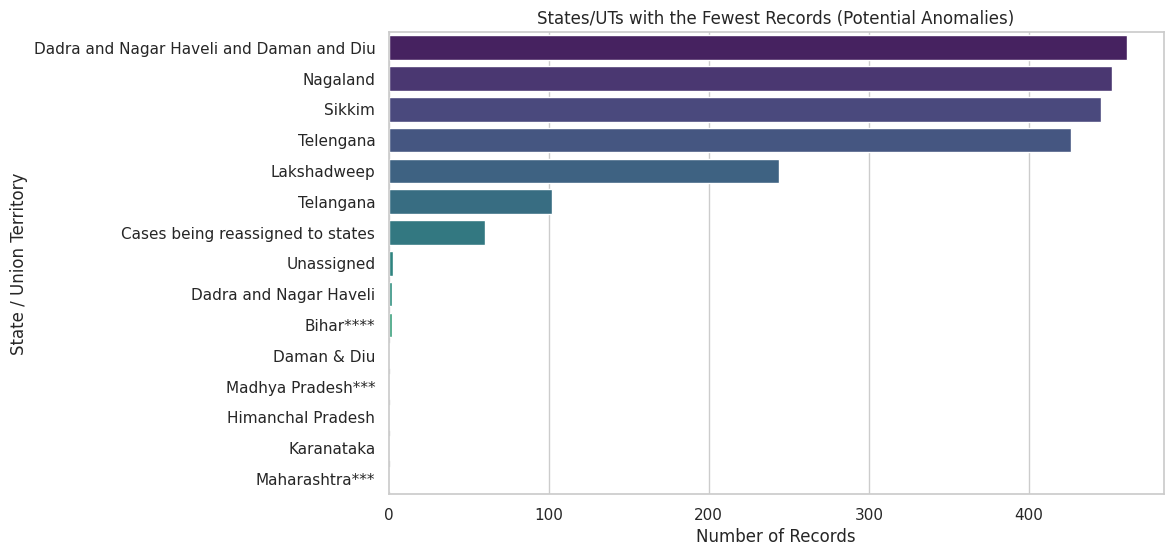

In [15]:
# Count the number of records for each state
state_counts = cases_df['State/UnionTerritory'].value_counts().reset_index()
state_counts.columns = ['State', 'Record Count']

# plot the bottom 15 states by record count, as typo's usually occur rarely
plt.figure(figsize=(10, 6))
sns.barplot(data=state_counts.tail(15), y='State', x='Record Count', palette='viridis', hue='State')
plt.title('States/UTs with the Fewest Records (Potential Anomalies)')
plt.xlabel('Number of Records')
plt.ylabel('State / Union Territory')
plt.show()

### Insights (Cases Data)
Looking at the lowest frequency categories, we clearly spot several issues:
- **Typos**: `Karanataka`, `Himanchal Pradesh`, `Telengana`
- **Special Characters**: `Bihar****`, `Madhya Pradesh***`, `Maharashtra***`
- **Unassigned/Reassigned Data**: `Unassigned`, `Cases being reassigned to states`
- **Repetition**: `Daman & Diu` , `Dadra and Nagar Haveli` ,`Dadra and Nagar Haveli and Daman and Diu` only the combination should be kept.


## 4. Initial Data Inspection: Testing Dataset
Next, we examine the `testing_df`.

In [17]:
display(testing_df.head())
testing_df.info()

,Date,State,TotalSamples,Negative,Positive
0,2020-04-17,Andaman and Nicobar Islands,1403.0,1210,12.0
1,2020-04-24,Andaman and Nicobar Islands,2679.0,NaN,27.0
2,2020-04-27,Andaman and Nicobar Islands,2848.0,NaN,33.0
3,2020-05-01,Andaman and Nicobar Islands,3754.0,NaN,33.0
4,2020-05-16,Andaman and Nicobar Islands,6677.0,NaN,33.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16336 entries, 0 to 16335
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          16336 non-null  object 
 1   State         16336 non-null  object 
 2   TotalSamples  16336 non-null  float64
 3   Negative      6969 non-null   object 
 4   Positive      5662 non-null   float64
dtypes: float64(2), object(3)
memory usage: 638.3+ KB


In [18]:
testing_df.describe()

,TotalSamples,Positive
count,1.633600e+04,5.662000e+03
mean,5.376466e+06,5.652654e+04
std,8.780338e+06,1.673108e+05
min,5.800000e+01,0.000000e+00
25%,1.729098e+05,5.362500e+02
50%,9.307580e+05,4.771000e+03
75%,7.284795e+06,3.361875e+04
max,6.789786e+07,1.638961e+06


In [20]:
# the unique values in the 'State/UnionTerritory' column
unique_states = testing_df['State'].unique()
print(f"Number of unique states/UTs found: {len(unique_states)}\n")
print(unique_states)

Number of unique states/UTs found: 36

['Andaman and Nicobar Islands' 'Andhra Pradesh' 'Arunachal Pradesh'
 'Assam' 'Bihar' 'Chandigarh' 'Chhattisgarh'
 'Dadra and Nagar Haveli and Daman and Diu' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu and Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Ladakh' 'Lakshadweep' 'Madhya Pradesh' 'Maharashtra' 'Manipur'
 'Meghalaya' 'Mizoram' 'Nagaland' 'Odisha' 'Puducherry' 'Punjab'
 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura' 'Uttar Pradesh'
 'Uttarakhand' 'West Bengal']


### Insights (Testing Data)
1. **Missing Values**: there are a lot of missing values for `positive` and `negative` columns, moreover there are values missing for `negative` even when `positive` contains a value.
2. **State Names**: are perfect in this dataset unlike cases data

## 5. Initial Data Inspection: vaccine dataset


In [25]:
display(vaccine_df.head())
vaccine_df.info()
display(vaccine_df.sample(5))

,Updated On,State,Total Doses Administered,Sessions,Sites,First Dose Administered,Second Dose Administered,Male (Doses Administered),Female (Doses Administered),Transgender (Doses Administered),...,18-44 Years (Doses Administered),45-60 Years (Doses Administered),60+ Years (Doses Administered),18-44 Years(Individuals Vaccinated),45-60 Years(Individuals Vaccinated),60+ Years(Individuals Vaccinated),Male(Individuals Vaccinated),Female(Individuals Vaccinated),Transgender(Individuals Vaccinated),Total Individuals Vaccinated
0,16/01/2021,India,48276.0,3455.0,2957.0,48276.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,23757.0,24517.0,2.0,48276.0
1,17/01/2021,India,58604.0,8532.0,4954.0,58604.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,27348.0,31252.0,4.0,58604.0
2,18/01/2021,India,99449.0,13611.0,6583.0,99449.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,41361.0,58083.0,5.0,99449.0
3,19/01/2021,India,195525.0,17855.0,7951.0,195525.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,81901.0,113613.0,11.0,195525.0
4,20/01/2021,India,251280.0,25472.0,10504.0,251280.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,98111.0,153145.0,24.0,251280.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7845 entries, 0 to 7844
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Updated On                           7845 non-null   object 
 1   State                                7845 non-null   object 
 2   Total Doses Administered             7621 non-null   float64
 3   Sessions                             7621 non-null   float64
 4    Sites                               7621 non-null   float64
 5   First Dose Administered              7621 non-null   float64
 6   Second Dose Administered             7621 non-null   float64
 7   Male (Doses Administered)            7461 non-null   float64
 8   Female (Doses Administered)          7461 non-null   float64
 9   Transgender (Doses Administered)     7461 non-null   float64
 10   Covaxin (Doses Administered)        7621 non-null   float64
 11  CoviShield (Doses Administered

,Updated On,State,Total Doses Administered,Sessions,Sites,First Dose Administered,Second Dose Administered,Male (Doses Administered),Female (Doses Administered),Transgender (Doses Administered),...,18-44 Years (Doses Administered),45-60 Years (Doses Administered),60+ Years (Doses Administered),18-44 Years(Individuals Vaccinated),45-60 Years(Individuals Vaccinated),60+ Years(Individuals Vaccinated),Male(Individuals Vaccinated),Female(Individuals Vaccinated),Transgender(Individuals Vaccinated),Total Individuals Vaccinated
6198,06/03/2021,Rajasthan,2024053.0,45889.0,5687.0,1704633.0,319420.0,970477.0,733943.0,213.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1704633.0
2612,24/03/2021,Haryana,1172883.0,104550.0,536.0,1035137.0,137746.0,549677.0,485372.0,88.0,...,NaN,NaN,NaN,178312.0,247592.0,607733.0,NaN,NaN,NaN,1035137.0
1760,21/03/2021,Dadra and Nagar Haveli and Daman and Diu,23840.0,200.0,2.0,19218.0,4622.0,9921.0,9297.0,0.0,...,NaN,NaN,NaN,6359.0,5095.0,7753.0,NaN,NaN,NaN,19218.0
3843,11/02/2021,Ladakh,2597.0,66.0,33.0,2597.0,0.0,768.0,1829.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2597.0
4896,04/02/2021,Meghalaya,4216.0,198.0,86.0,4216.0,0.0,1463.0,2753.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4216.0


In [23]:
# the unique values in the 'State/UnionTerritory' column
unique_states = vaccine_df['State'].unique()
print(f"Number of unique states/UTs found: {len(unique_states)}\n")
print(unique_states)

Number of unique states/UTs found: 37

['India' 'Andaman and Nicobar Islands' 'Andhra Pradesh'
 'Arunachal Pradesh' 'Assam' 'Bihar' 'Chandigarh' 'Chhattisgarh'
 'Dadra and Nagar Haveli and Daman and Diu' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu and Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Ladakh' 'Lakshadweep' 'Madhya Pradesh' 'Maharashtra' 'Manipur'
 'Meghalaya' 'Mizoram' 'Nagaland' 'Odisha' 'Puducherry' 'Punjab'
 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura' 'Uttar Pradesh'
 'Uttarakhand' 'West Bengal']


In [24]:
vaccine_df[vaccine_df['State']=='India']

,Updated On,State,Total Doses Administered,Sessions,Sites,First Dose Administered,Second Dose Administered,Male (Doses Administered),Female (Doses Administered),Transgender (Doses Administered),...,18-44 Years (Doses Administered),45-60 Years (Doses Administered),60+ Years (Doses Administered),18-44 Years(Individuals Vaccinated),45-60 Years(Individuals Vaccinated),60+ Years(Individuals Vaccinated),Male(Individuals Vaccinated),Female(Individuals Vaccinated),Transgender(Individuals Vaccinated),Total Individuals Vaccinated
0,16/01/2021,India,48276.0,3455.0,2957.0,48276.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,23757.0,24517.0,2.0,48276.0
1,17/01/2021,India,58604.0,8532.0,4954.0,58604.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,27348.0,31252.0,4.0,58604.0
2,18/01/2021,India,99449.0,13611.0,6583.0,99449.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,41361.0,58083.0,5.0,99449.0
3,19/01/2021,India,195525.0,17855.0,7951.0,195525.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,81901.0,113613.0,11.0,195525.0
4,20/01/2021,India,251280.0,25472.0,10504.0,251280.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,98111.0,153145.0,24.0,251280.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,11/08/2021,India,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208,12/08/2021,India,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209,13/08/2021,India,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210,14/08/2021,India,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
mask = (vaccine_df['Updated On'] == '16/01/2021') & (vaccine_df['State'] != "India")
vaccine_df[mask].select_dtypes(include='Float64').sum(axis=0)

Total Doses Administered               48276.0
Sessions                                3455.0
 Sites                                  2957.0
First Dose Administered                48276.0
Second Dose Administered                   0.0
Male (Doses Administered)              23757.0
Female (Doses Administered)            24517.0
Transgender (Doses Administered)           2.0
 Covaxin (Doses Administered)            579.0
CoviShield (Doses Administered)        47697.0
Sputnik V (Doses Administered)             0.0
AEFI                                       0.0
18-44 Years (Doses Administered)           0.0
45-60 Years (Doses Administered)           0.0
60+ Years (Doses Administered)             0.0
18-44 Years(Individuals Vaccinated)        0.0
45-60 Years(Individuals Vaccinated)        0.0
60+ Years(Individuals Vaccinated)          0.0
Male(Individuals Vaccinated)               0.0
Female(Individuals Vaccinated)             0.0
Transgender(Individuals Vaccinated)        0.0
Total Individ

In [32]:
vaccine_df[(vaccine_df['State']=='India') & (vaccine_df['Updated On']=='16/01/2021')]

,Updated On,State,Total Doses Administered,Sessions,Sites,First Dose Administered,Second Dose Administered,Male (Doses Administered),Female (Doses Administered),Transgender (Doses Administered),...,18-44 Years (Doses Administered),45-60 Years (Doses Administered),60+ Years (Doses Administered),18-44 Years(Individuals Vaccinated),45-60 Years(Individuals Vaccinated),60+ Years(Individuals Vaccinated),Male(Individuals Vaccinated),Female(Individuals Vaccinated),Transgender(Individuals Vaccinated),Total Individuals Vaccinated
0,16/01/2021,India,48276.0,3455.0,2957.0,48276.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,23757.0,24517.0,2.0,48276.0


### Insights
- There was India mentioned as state and rows included its data.
- Using above analysis we see that it represents the all states data collectively mentioned as India.
- We will need to handle this accordingly.